# Task 5: Exploratory Data Analysis & Visualization (EDA)
**Objective:** Analyze seasonal trends, district comparisons, correlations, and diurnal rush-hour patterns using the cleaned air quality dataset.


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Set aesthetic style for all plots
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# 1. Load Daily Merged Data
df_daily = pd.read_csv('/clean_daily_merged.csv')
df_daily['day'] = pd.to_datetime(df_daily['day'])

# 2. Load Hourly Meteo Data
df_hourly = pd.read_csv('/clean_hourly_meteo.csv')
df_hourly['date'] = pd.to_datetime(df_hourly['date'])
df_hourly['hour'] = df_hourly['date'].dt.hour

print("✅ Data Loaded Successfully!")
print("Daily Data Shape:", df_daily.shape)
print("Hourly Data Shape:", df_hourly.shape)


✅ Data Loaded Successfully!
Daily Data Shape: (5480, 76)
Hourly Data Shape: (131520, 19)


## 1. Seasonal Trends (Time-Series)
Analyzing the overall trend of PM2.5 across the year for all stations.


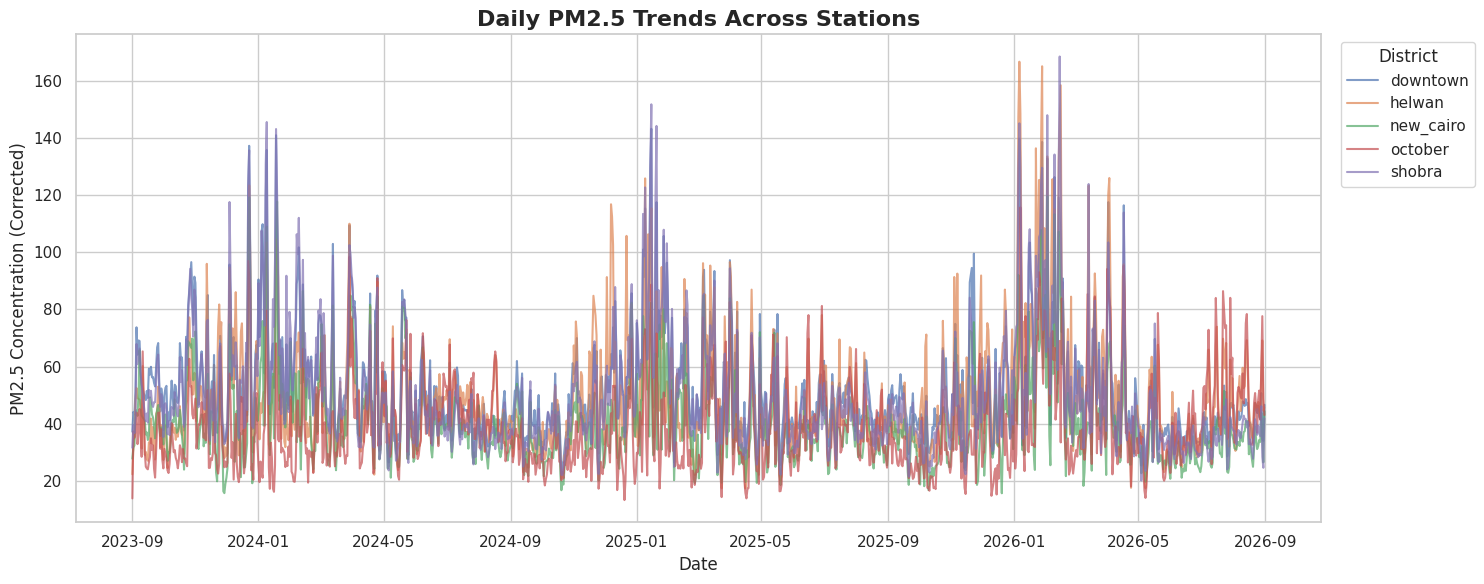

In [7]:
plt.figure(figsize=(15, 6))
sns.lineplot(data=df_daily, x='day', y='pm2_5_corrected', hue='station_id', alpha=0.7)
plt.title('Daily PM2.5 Trends Across Stations', fontsize=16, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('PM2.5 Concentration (Corrected)', fontsize=12)
plt.legend(title='District', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('1_pm25_trends.png')
plt.show()


## 2. Khamsin Season Focus (March - May)
Highlighting the massive PM10 spikes caused by spring dust storms, particularly in desert/industrial areas like 6th of October and Helwan.


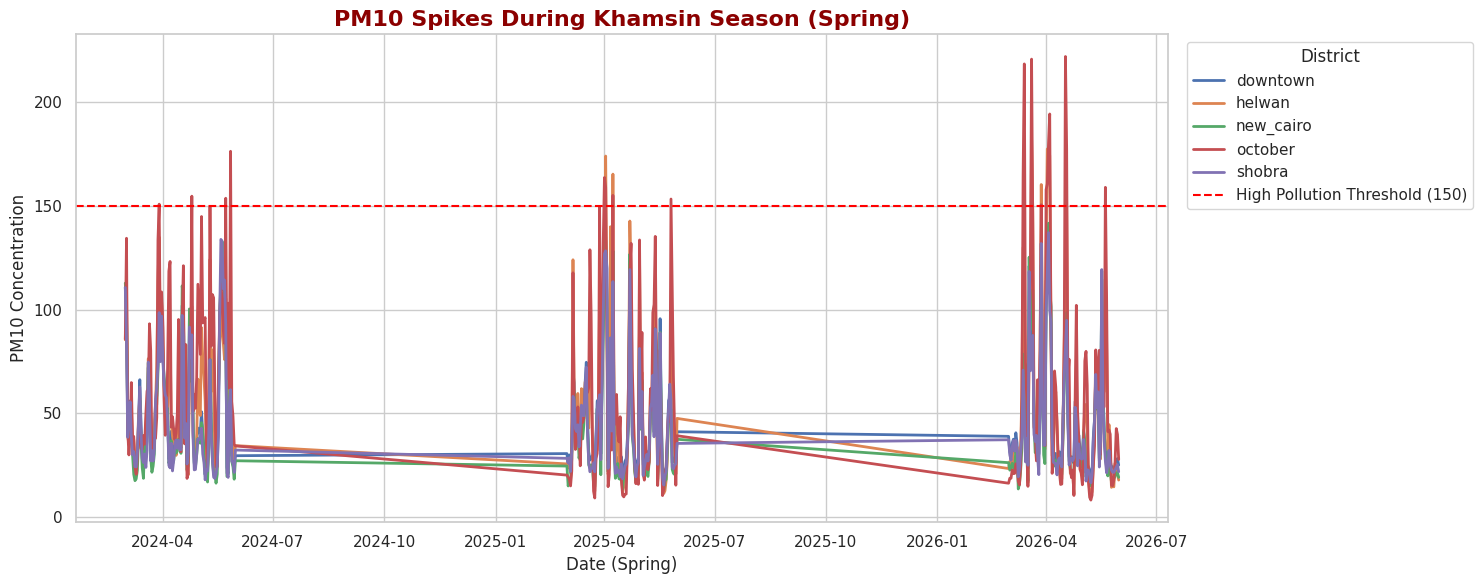

In [8]:
# Filter data for Spring (March, April, May)
df_spring = df_daily[df_daily['day'].dt.month.isin([3, 4, 5])]

plt.figure(figsize=(15, 6))
sns.lineplot(data=df_spring, x='day', y='pm10', hue='station_id', linewidth=2)
plt.title('PM10 Spikes During Khamsin Season (Spring)', fontsize=16, fontweight='bold', color='darkred')
plt.xlabel('Date (Spring)', fontsize=12)
plt.ylabel('PM10 Concentration', fontsize=12)
plt.axhline(y=150, color='red', linestyle='--', label='High Pollution Threshold (150)')
plt.legend(title='District', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.savefig('2_khamsin_pm10.png')
plt.show()


## 3. District Comparisons
Comparing the distribution and extreme values of PM2.5 across different geographical areas.


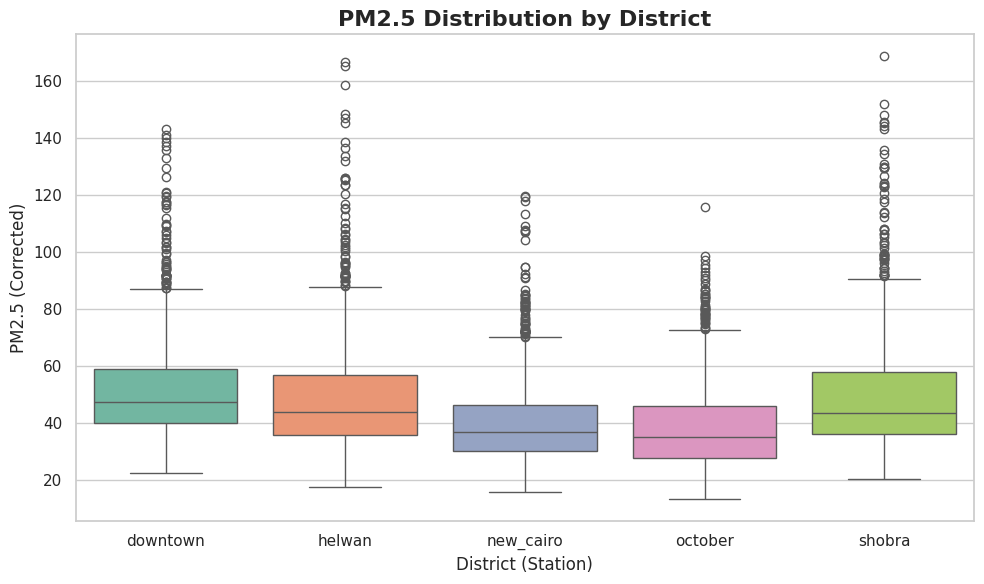

In [9]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_daily, x='station_id', y='pm2_5_corrected', palette='Set2')
plt.title('PM2.5 Distribution by District', fontsize=16, fontweight='bold')
plt.xlabel('District (Station)', fontsize=12)
plt.ylabel('PM2.5 (Corrected)', fontsize=12)
plt.tight_layout()
plt.savefig('3_district_boxplot.png')
plt.show()


## 4. Correlation Matrix
Investigating the relationships between surface pollutants, satellite observations (Sentinel-5P), and weather metrics.


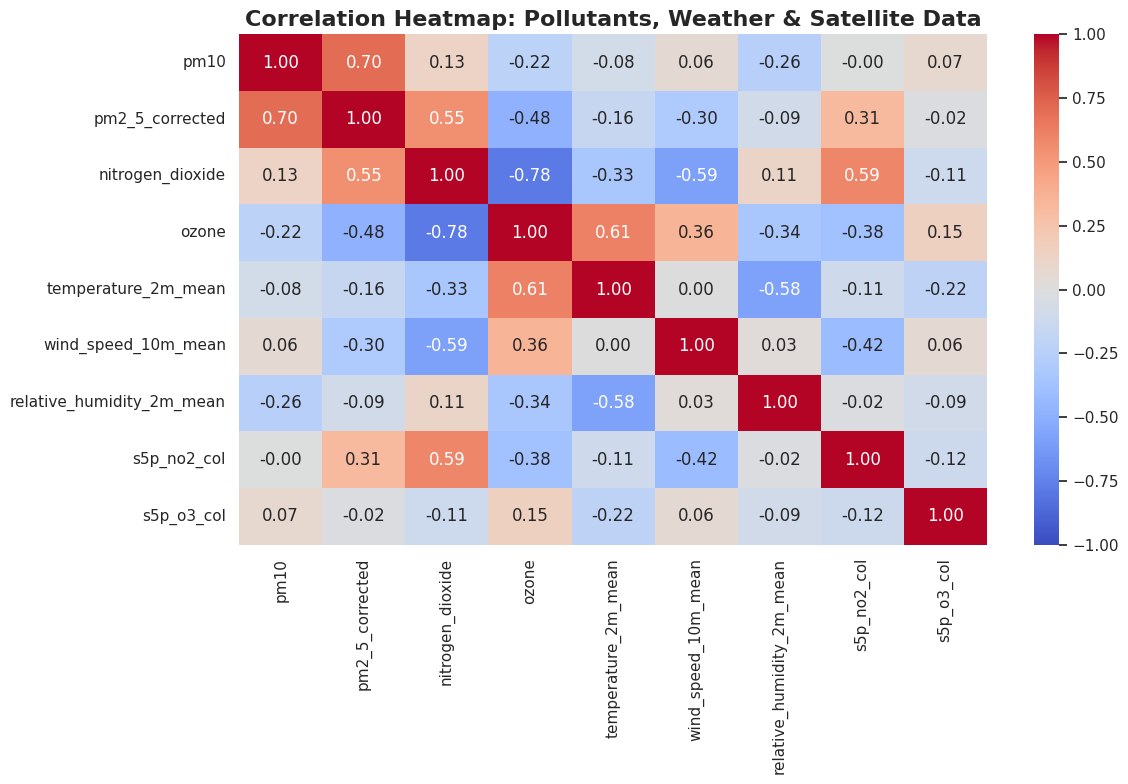

In [10]:
cols_to_correlate = [
    'pm10', 'pm2_5_corrected', 'nitrogen_dioxide', 'ozone',
    'temperature_2m_mean', 'wind_speed_10m_mean', 'relative_humidity_2m_mean',
    's5p_no2_col', 's5p_o3_col'
]

corr_matrix = df_daily[cols_to_correlate].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap: Pollutants, Weather & Satellite Data', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('4_correlation_heatmap.png')
plt.show()


## 5. Intraday Patterns & Rush Hours (Diurnal Cycles)
Using the **Hourly File** to track how pollution peaks during morning and evening rush hours.


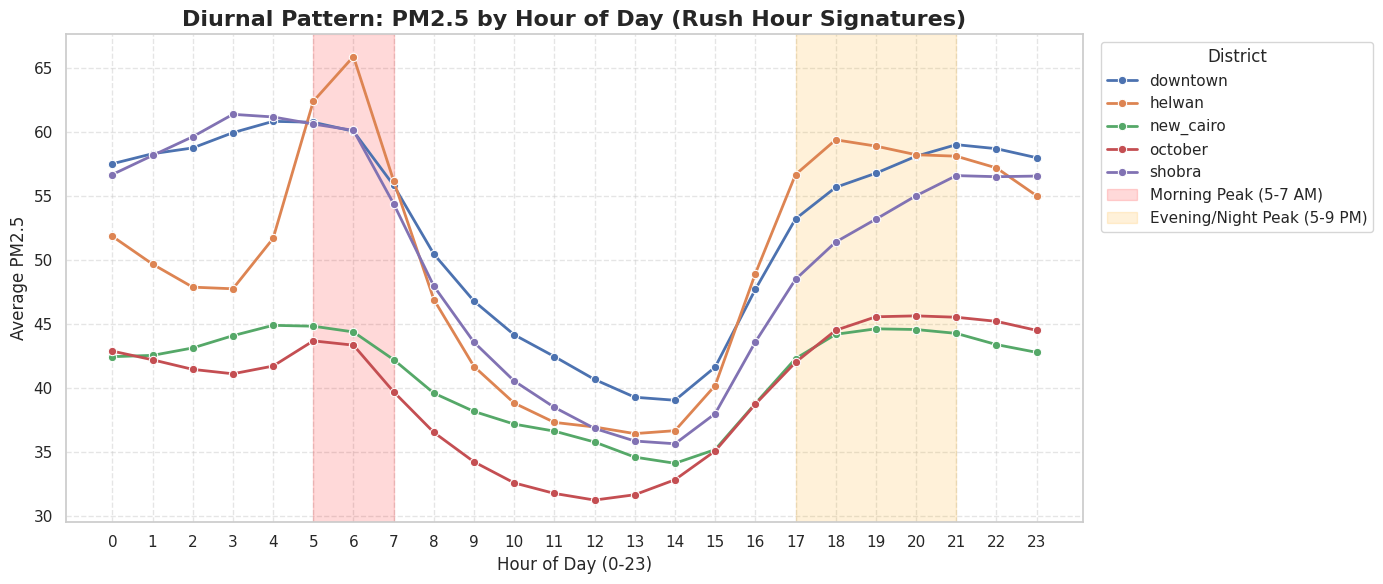

In [12]:
# Calculate average PM2.5 per hour per station
hourly_pattern = df_hourly.groupby(['hour', 'station_id'])['pm2_5'].mean().reset_index()

plt.figure(figsize=(14, 6))
sns.lineplot(data=hourly_pattern, x='hour', y='pm2_5', hue='station_id', marker='o', linewidth=2)

plt.title('Diurnal Pattern: PM2.5 by Hour of Day (Rush Hour Signatures)', fontsize=16, fontweight='bold')
plt.xlabel('Hour of Day (0-23)', fontsize=12)
plt.ylabel('Average PM2.5', fontsize=12)
plt.xticks(range(0, 24))

# Highlight rush hours
plt.axvspan(5, 7, color='red', alpha=0.15, label='Morning Peak (5-7 AM)')
plt.axvspan(17, 21, color='orange', alpha=0.15, label='Evening/Night Peak (5-9 PM)')

plt.legend(title='District', bbox_to_anchor=(1.01, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('5_hourly_rush_hour.png')
plt.show()
